파일 불러오기 및 날짜 타입 변환

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import calendar

df = pd.read_csv('/content/defects_data.csv')

# 날짜 타입 변환
format='%Y-%m-%dT'
df['defect_date'] = pd.to_datetime(df['defect_date'], format='mixed')

df

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,2024-06-06,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,2024-04-26,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2024-02-15,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,2024-03-28,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,2024-04-26,Component,Minor,Manual Testing,823.64
...,...,...,...,...,...,...,...,...
995,996,25,Structural,2024-03-01,Component,Minor,Automated Testing,813.14
996,997,23,Functional,2024-03-21,Component,Moderate,Automated Testing,944.07
997,998,17,Structural,2024-01-16,Component,Minor,Automated Testing,401.12
998,999,96,Cosmetic,2024-06-21,Internal,Moderate,Manual Testing,775.63


# 2-1. product id 측면

수리 비용과 결함 수가 많은 제품을 개선하는 것이
비용 감소에 도움이 된다고 판단함.

따라서 이를 바탕으로 분석을 시작함.

In [ ]:
# product_id별로 repair_cost 합계와 발생 빈도 계산
product_stats = df.groupby('product_id').agg(
    total_repair_cost=('repair_cost', 'sum'),
    defect_count=('product_id', 'count')
).reset_index()

# total_repair_cost와 defect_count 기준으로 정렬
product_stats = product_stats.sort_values(
    by=['total_repair_cost', 'defect_count'],
    ascending=[False, False]
)

product_stats.head(13)

,product_id,total_repair_cost,defect_count
80,81,11740.64,20
9,10,10084.92,16
55,56,9916.30,18
44,45,9532.36,15
62,63,9174.06,20
5,6,8733.81,15
73,74,8460.54,15
48,49,8419.22,12
96,97,8405.84,19
76,77,7657.37,14


위에서 정렬된 제품 중 상위 10%를 기준으로 분석 진행



---



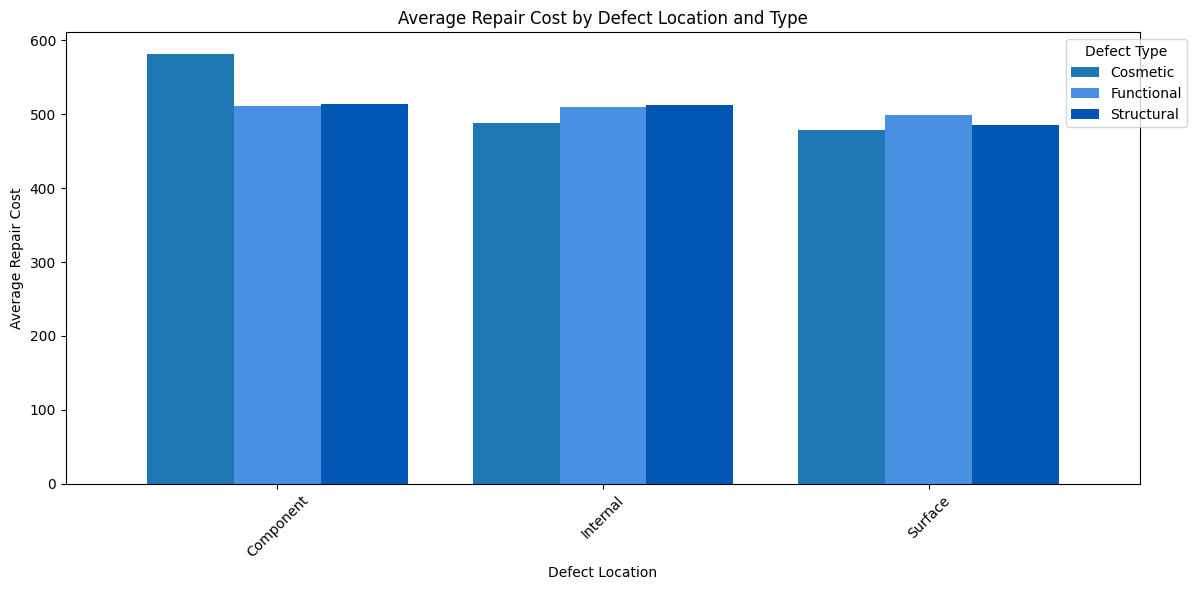

In [ ]:
# 결함 위치와 유형별 평균 수리 비용
# 수리 비용이 가장 많은 붑분이 cosmetic + component 임을 알아낸 코드

custom_colors = ['#1f77b4', '#4a90e2', '#0056b3']
location_type_cost_mean = df.groupby(['defect_location', 'defect_type'])['repair_cost'].mean().unstack()

location_type_cost_mean.plot(kind='bar', figsize=(12, 6), color=custom_colors, width=0.8)

plt.title('Average Repair Cost by Defect Location and Type')
plt.xlabel('Defect Location')
plt.ylabel('Average Repair Cost')
plt.legend(title='Defect Type', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

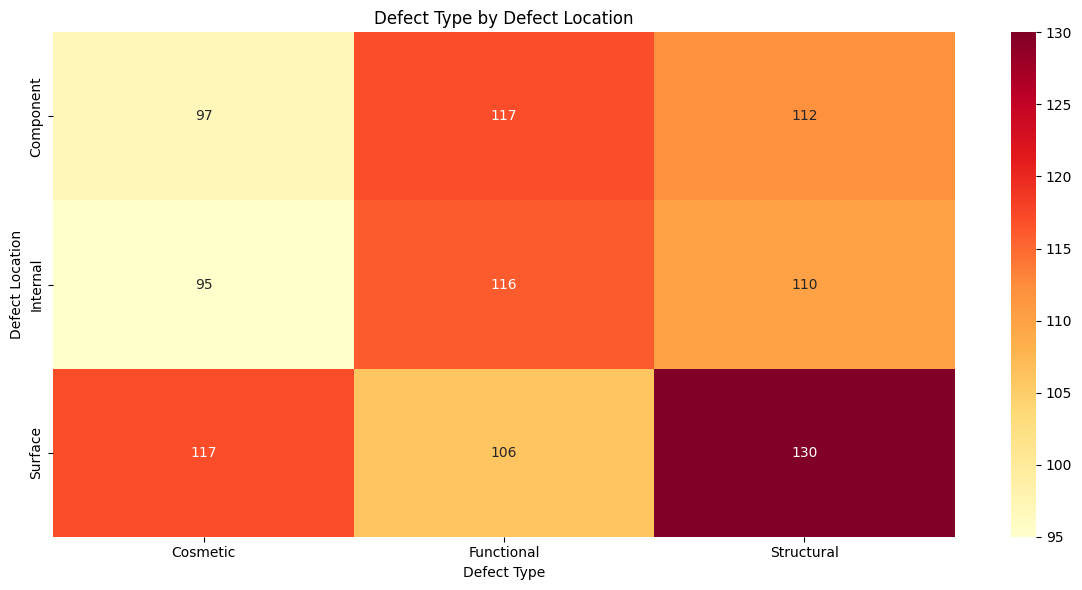

In [ ]:
# 결함 유형과 결함 위치 heatmap
# 결함 발생이 surface + structural 임을 알아낸 코드

location_type_counts = df.groupby('defect_location')['defect_type'].value_counts().unstack()

# Plotting the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(location_type_counts, annot=True, cmap='YlOrRd', fmt='g')

plt.title('Defect Type by Defect Location')
plt.xlabel('Defect Type')
plt.ylabel('Defect Location')
plt.tight_layout()
plt.show()

In [ ]:
# 앞부분에 보여줄 product_id(시각화를 편리하게 하기 위한 과정)
priority_product_ids = [81, 10, 56, 45, 63, 6, 74, 49, 97, 77]

# cosmetic+component&structural+surface인 제품 필터링
filtered_df = df[
    ((df['defect_type'] == 'Cosmetic') & (df['defect_location'] == 'Component')) |
    ((df['defect_type'] == 'Structural') & (df['defect_location'] == 'Surface'))
]

# 데이터 합치기 및 결함 개수 계산
aggregated_df = (
    filtered_df.groupby(['product_id', 'defect_type', 'defect_location'])
    .agg(defect_count=('product_id', 'size'),total_repair_cost=('repair_cost', 'sum'))
    .reset_index()
)

# 우선순위 열 추가 및 정렬
aggregated_df['priority'] = aggregated_df['product_id'].apply(
    lambda x: priority_product_ids.index(x) if x in priority_product_ids else float('inf')
)

final_filtered_df = aggregated_df.sort_values(by='priority').drop(columns='priority')

final_filtered_df.reset_index(drop=True, inplace=True)
final_filtered_df.head(23)

,product_id,defect_type,defect_location,defect_count,total_repair_cost
0,81,Cosmetic,Component,1,368.11
1,81,Structural,Surface,1,471.55
2,10,Structural,Surface,1,342.61
3,10,Cosmetic,Component,1,830.39
4,56,Cosmetic,Component,2,1227.46
5,56,Structural,Surface,2,948.77
6,45,Structural,Surface,3,1877.30
7,45,Cosmetic,Component,1,576.07
8,63,Structural,Surface,5,2258.37
9,63,Cosmetic,Component,1,538.99


위 출력 결과는 cosmetic+component이면서 structural+surface인 결함을 가진 제품 중 일부분이다.

해당 제품 중에 6,77번을 제외한 상위 10%(repair cost, defect count 높은 순)의 제품이 포함되어 있다.

따라서 중복된 제품의 월별 결함 수를 그래프로 시각화하여 경향을 파악하였다.

* 위 표에서 각 제품의 결함 수가 적은 것을 볼 수 있다. 하지만 각 제품 총 결함 수에서 차지하는 비율이 10% 이상이기에 해당 제품을 분석 제품에 포함하였다.



---

먼저 전체 제품의 월별 결함 수 그래프를 그려보았다.

아래 그래프에서 볼 수 있듯이, 큰 경향성을 보이지 않는 것을 알 수 있다.

그러면 각 제품별 월별 결함 수 그래프는 어떤 경향을 보이는지 알아보도록 하자.

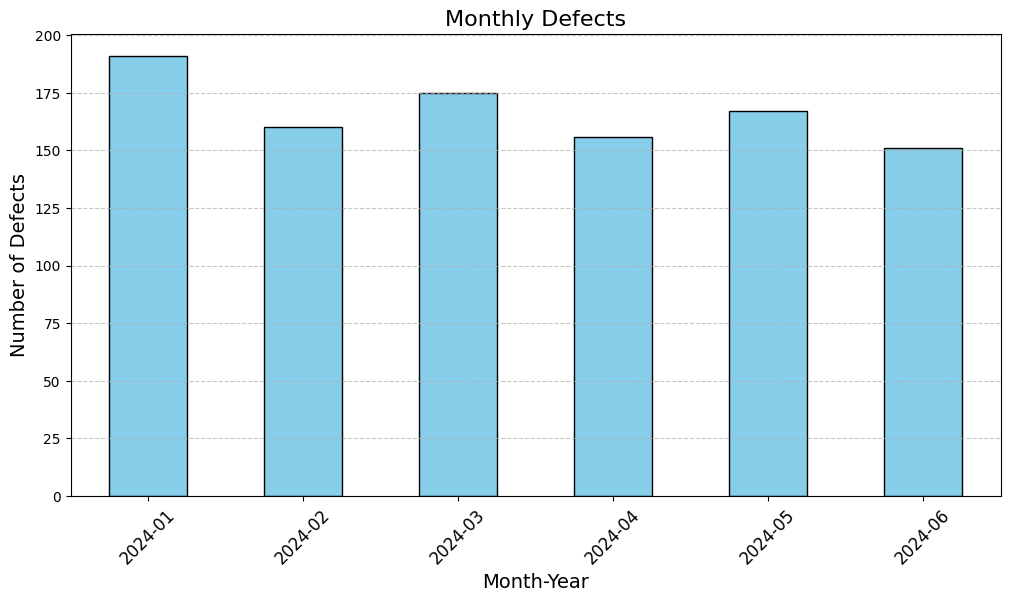

In [ ]:
# month_year 컬럼 추가 (월-연 정보)
df['month_year'] = df['defect_date'].dt.to_period('M')

# month_year 기준으로 결함 수 집계
monthly_defects = df.groupby('month_year').size()

# 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()



---

각 제품의 월별 결함 수 그래프

81번 제품

6월에 결함 수가 0으로, 결함이 감소하는 추세를 보임. 하지만 안정적이지 않기에 지속적인 품질 관리 필요.

<ipython-input-17-095232cc185e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_81_data['month_year'] = product_81_data['defect_date'].dt.to_period('M')


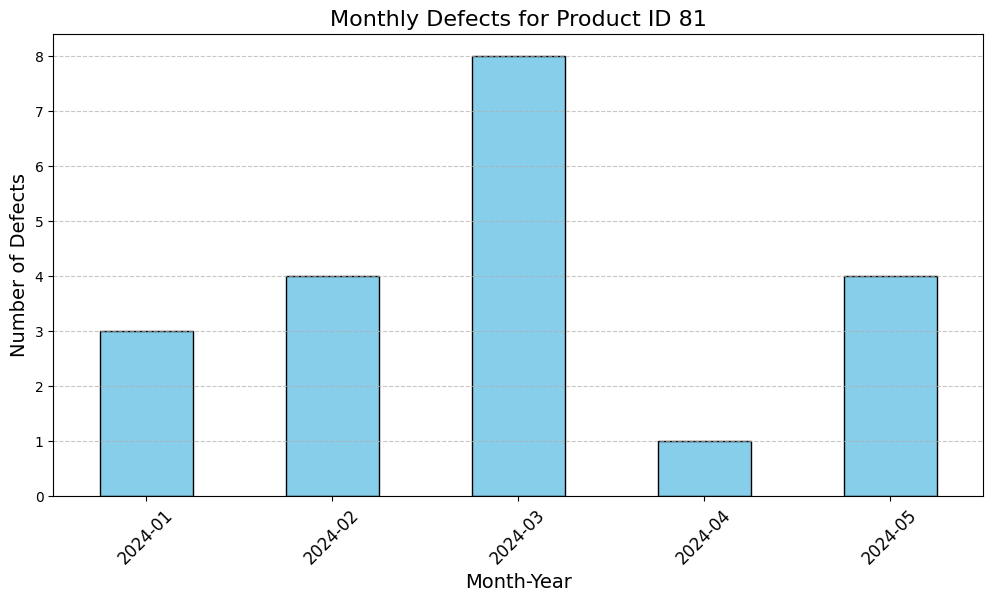

In [ ]:
# 81번 제품 데이터 필터링
product_81_data = df[df['product_id'] == 81]

# month_year 컬럼 추가 (월-연 정보)
product_81_data['month_year'] = product_81_data['defect_date'].dt.to_period('M')

# month_year 기준으로 결함 수 집계
monthly_defects = product_81_data.groupby('month_year').size()

# 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 81', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

63, 97번 제품

최근 3개월 동안 감소하는 추세를 보임. 하지만 지속적인 모니터링으로 품질 유지 필요.

<ipython-input-18-ca504e4e4333>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_63_data['month_year'] = product_63_data['defect_date'].dt.to_period('M')


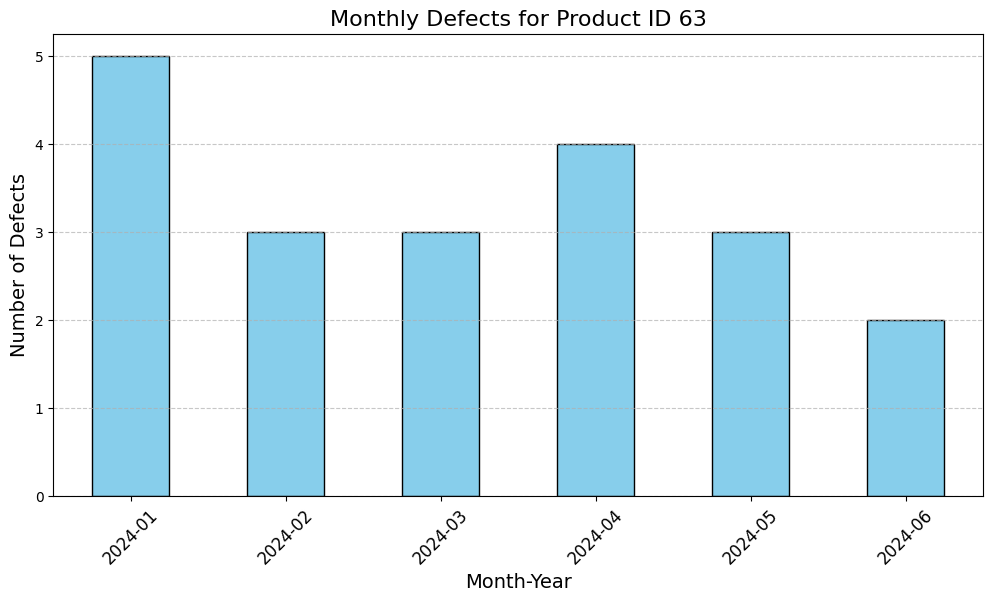

In [ ]:
# 63번 제품 데이터 필터링
product_63_data = df[df['product_id'] == 63]

# 월-연 컬럼 추가
product_63_data['month_year'] = product_63_data['defect_date'].dt.to_period('M')

# 월별 결함 빈도 계산
monthly_defects_63 = product_63_data.groupby('month_year').size()

# 월별 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects_63.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 63', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

<ipython-input-19-1bd307562cc3>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_97_data['month_year'] = product_97_data['defect_date'].dt.to_period('M')


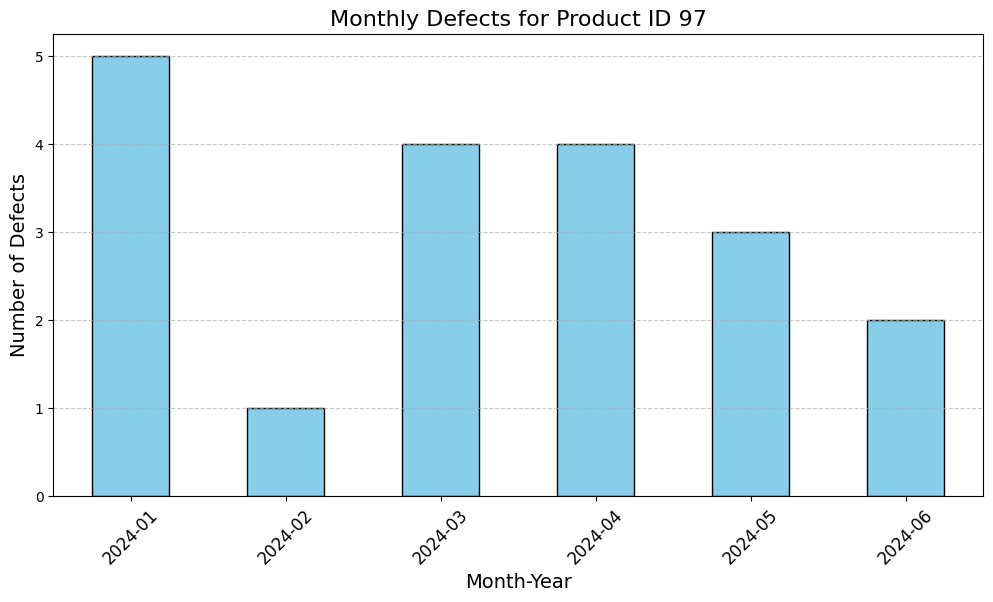

In [ ]:
# 97번 제품 데이터 필터링
product_97_data = df[df['product_id'] == 97]

# 월-연 컬럼 추가
product_97_data['month_year'] = product_97_data['defect_date'].dt.to_period('M')

# 월별 결함 빈도 계산
monthly_defects_97 = product_97_data.groupby('month_year').size()

# 월별 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects_97.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 97', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

10, 45번 제품

두 제품 모두 결함이 증가하는 추세를 보임(10번은 4월 제외, 45번은 5월 제외).  품질 개선이 필요하다고 판단.

<ipython-input-20-88125ffd789a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_10_data['month_year'] = product_10_data['defect_date'].dt.to_period('M')


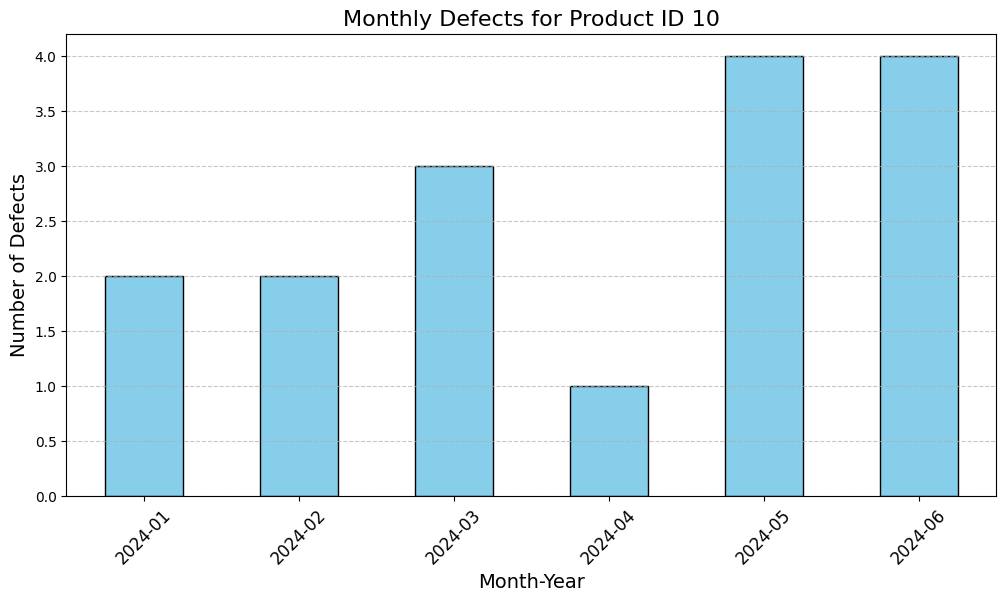

In [ ]:
# 10번 제품 데이터 필터링
product_10_data = df[df['product_id'] == 10]

# 월-연 컬럼 추가
product_10_data['month_year'] = product_10_data['defect_date'].dt.to_period('M')

# 월별 결함 빈도 계산
monthly_defects_10 = product_10_data.groupby('month_year').size()

# 월별 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects_10.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 10', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

<ipython-input-21-19f1745cd12f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_45_data['month_year'] = product_45_data['defect_date'].dt.to_period('M')


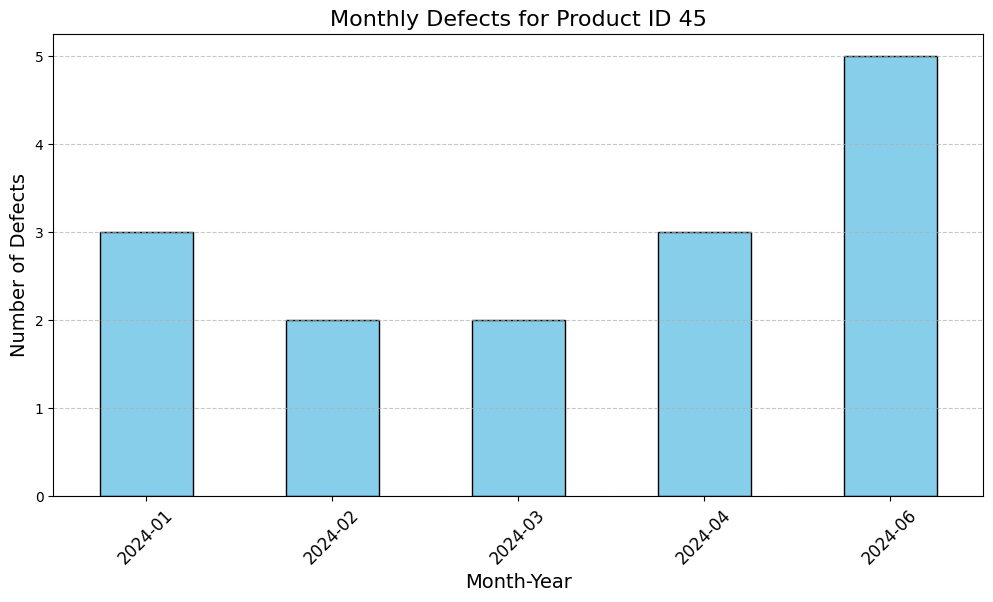

In [ ]:
# 45번 제품 데이터 필터링
product_45_data = df[df['product_id'] == 45]

# 월-연 컬럼 추가
product_45_data['month_year'] = product_45_data['defect_date'].dt.to_period('M')

# 월별 결함 빈도 계산
monthly_defects_45 = product_45_data.groupby('month_year').size()

# 월별 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects_45.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 45', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

56, 74, 49번 제품

두 제품 모두 결함의 감소와 증가가 반복됨. 따라서 해당 경향을 보이는 이유를 찾아 개선할 필요가 있어 보임.

<ipython-input-22-a40dd64199e0>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_56_data['month_year'] = product_56_data['defect_date'].dt.to_period('M')


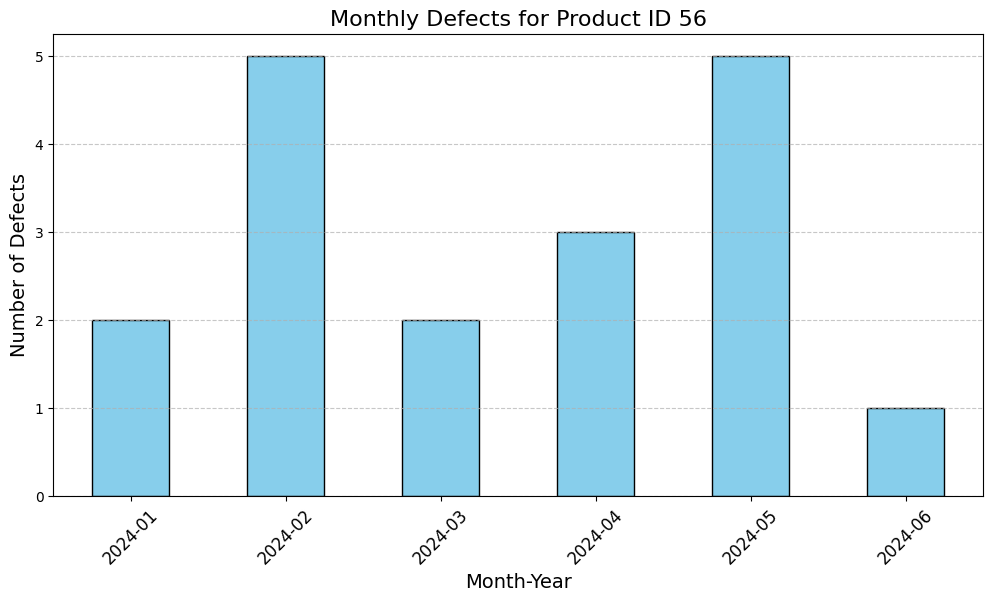

In [ ]:
# 56번 제품 데이터 필터링
product_56_data = df[df['product_id'] == 56]

# 월-연 컬럼 추가
product_56_data['month_year'] = product_56_data['defect_date'].dt.to_period('M')

# 월별 결함 빈도 계산
monthly_defects_56 = product_56_data.groupby('month_year').size()

# 월별 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects_56.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 56', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

<ipython-input-23-61a068288760>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_74_data['month_year'] = product_74_data['defect_date'].dt.to_period('M')


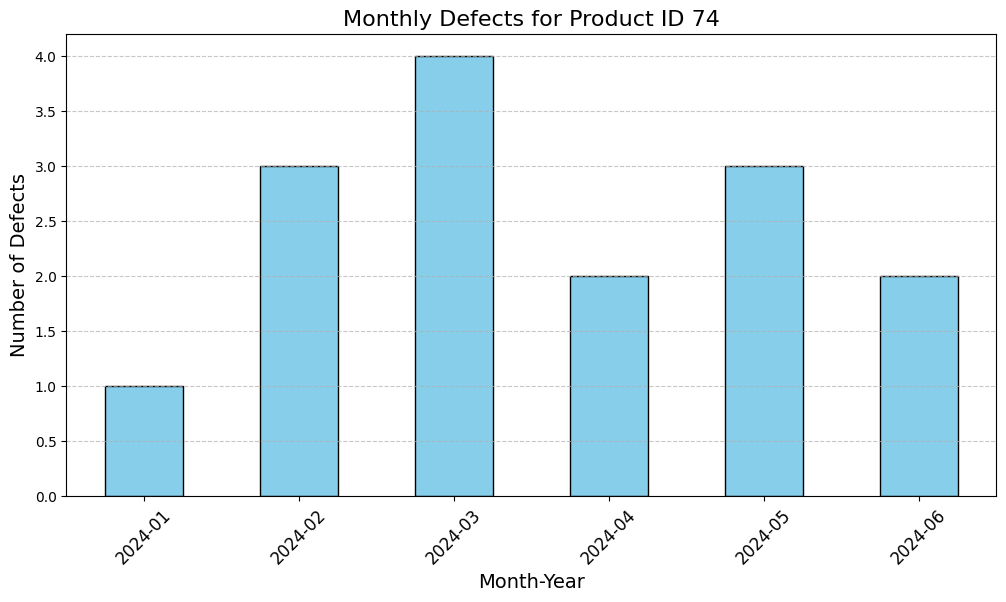

In [ ]:
# 74번 제품 데이터 필터링
product_74_data = df[df['product_id'] == 74]

# 월-연 컬럼 추가
product_74_data['month_year'] = product_74_data['defect_date'].dt.to_period('M')

# 월별 결함 빈도 계산
monthly_defects_74 = product_74_data.groupby('month_year').size()

# 월별 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects_74.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 74', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

<ipython-input-24-7dc6e3eb4415>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_49_data['month_year'] = product_49_data['defect_date'].dt.to_period('M')


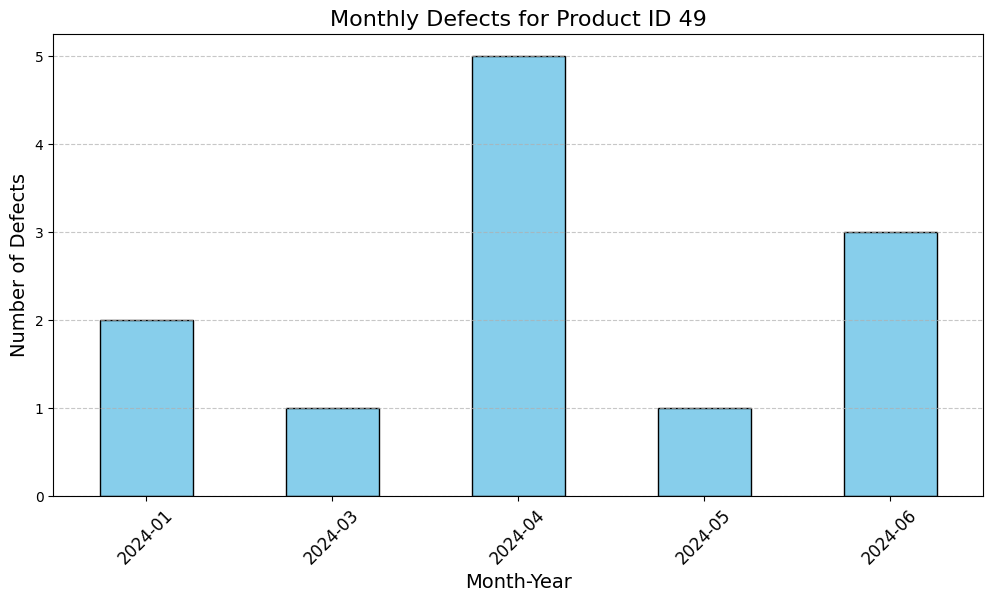

In [ ]:
# 49번 제품 데이터 필터링
product_49_data = df[df['product_id'] == 49]

# 월-연 컬럼 추가
product_49_data['month_year'] = product_49_data['defect_date'].dt.to_period('M')

# 월별 결함 빈도 계산
monthly_defects_49 = product_49_data.groupby('month_year').size()

# 월별 그래프 그리기
plt.figure(figsize=(12, 6))
monthly_defects_49.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Monthly Defects for Product ID 49', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Number of Defects', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

*product id 측면 분석 결과

제품 번호 : 10, 56, 45, 74, 49번


→ 해당 제품은 결함 수가 증가하거나, 증가와 감소를 반복하는 경향을 가짐.
따라서 해당 제품들의 품질을 개선할 필요가 있어 보임.

# 2-2. repair cost 측면

In [ ]:
defect_cost_extremes = df.groupby(["severity", "defect_type"])["repair_cost"].agg(["count","sum"]).reset_index()
print("\nCost Extremes by Severity and Defect Type:\n", defect_cost_extremes)


Cost Extremes by Severity and Defect Type:
    severity defect_type  count       sum
0  Critical    Cosmetic    107  50175.43
1  Critical  Functional    114  62447.91
2  Critical  Structural    112  55831.91
3     Minor    Cosmetic    106  57626.72
4     Minor  Functional    113  52802.23
5     Minor  Structural    139  73738.02
6  Moderate    Cosmetic     96  50995.57
7  Moderate  Functional    112  56655.44
8  Moderate  Structural    101  47353.92


Minor 항목 중에서
총 결함 수(count)와
총 수리 비용(sum)이 유독 튄다.

Minor와 Structural을 모두 포함하는 제품을 분석하기로 결정함.

In [ ]:
# 조건에 맞는 데이터 필터링
filtered_df = df[(df['defect_type'] == 'Structural') & (df['severity'] == 'Minor')]

# 수리비용 기준으로 내림차순 정렬
sorted_df = filtered_df.sort_values(by='repair_cost', ascending=False)

sorted_df

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
906,907,4,Structural,2024-02-16,Component,Minor,Visual Inspection,988.05
163,164,6,Structural,2024-04-20,Internal,Minor,Visual Inspection,986.51
55,56,73,Structural,2024-01-19,Surface,Minor,Automated Testing,957.60
808,809,8,Structural,2024-03-19,Surface,Minor,Visual Inspection,956.44
564,565,58,Structural,2024-01-15,Surface,Minor,Manual Testing,946.80
...,...,...,...,...,...,...,...,...
144,145,25,Structural,2024-01-16,Internal,Minor,Manual Testing,23.02
125,126,29,Structural,2024-02-01,Surface,Minor,Visual Inspection,21.77
611,612,56,Structural,2024-04-13,Internal,Minor,Manual Testing,21.12
775,776,37,Structural,2024-05-02,Surface,Minor,Automated Testing,20.93


위 표는 Structural + Minor인 제품의 총 수리비용 높은 순으로 나열한 것으로 이를 시각화하면 다음 코드와 같다.

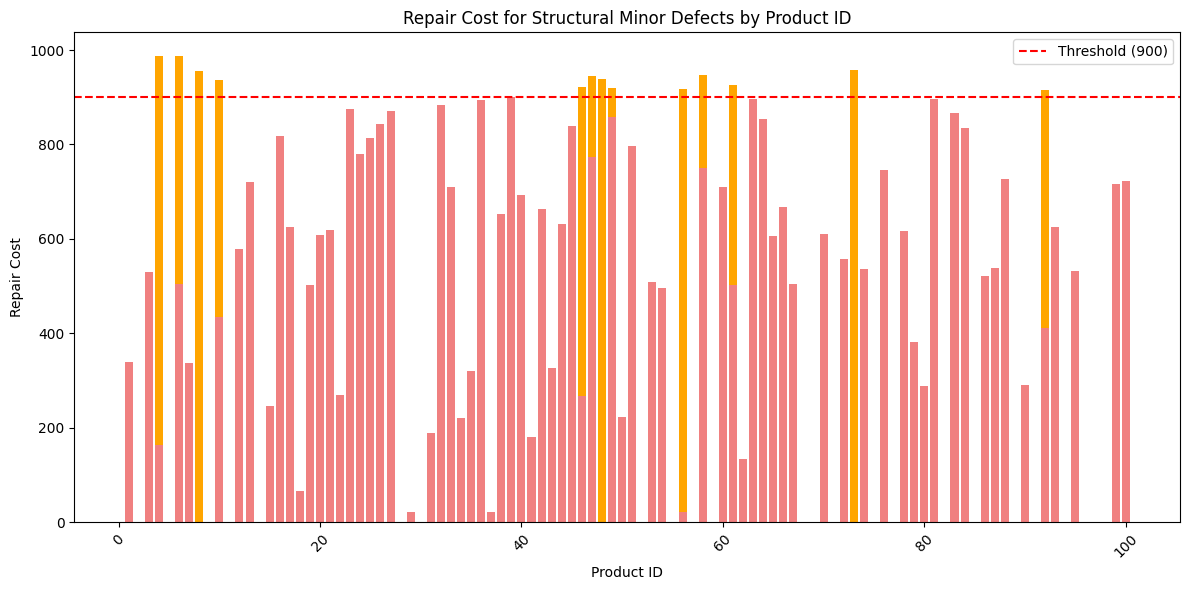

In [ ]:
# 색상 설정
colors = ['lightcoral' if cost <= 900 else 'orange' for cost in sorted_df['repair_cost']]

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.bar(sorted_df['product_id'], sorted_df['repair_cost'], color=colors)
plt.title('Repair Cost for Structural Minor Defects by Product ID')
plt.xlabel('Product ID')
plt.ylabel('Repair Cost')
plt.xticks(rotation=45)
plt.axhline(y=900, color='red', linestyle='--', label='Threshold (900)')
plt.legend()
plt.tight_layout()
plt.show()

위 그래프에서 총 repair cost가 900 이상인 제품을 추출하여 분석에 사용함.

* 기준을 900으로 설정한 이유 : 그래프에서 높이 솟아있는 값을 추출하고자 했는데, 800을 기준으로 하면 상당히 많은 수의 제품을 분석해야하기에, 900을 기준으로 하는 것이 적당하다고 생각하였다.

* 그래프가 겹치는 이유: 특정 제품당 결함이 두 개씩 존재하는 경우, 결함이 위로 쌓이는 형태로 나타남

<repair cost 측면 분석 결과>

제품 번호 : 4, 6, 73, 8, 58, 47, 48, 10,
           61, 46, 49, 56, 92번

→ 해당 제품은 결함 수와 총 수리 비용이 많은 minor와 structural에
해당하면서 각 제품별 수리 비용이 900 이상에 해당

# 2-3. Date 측면

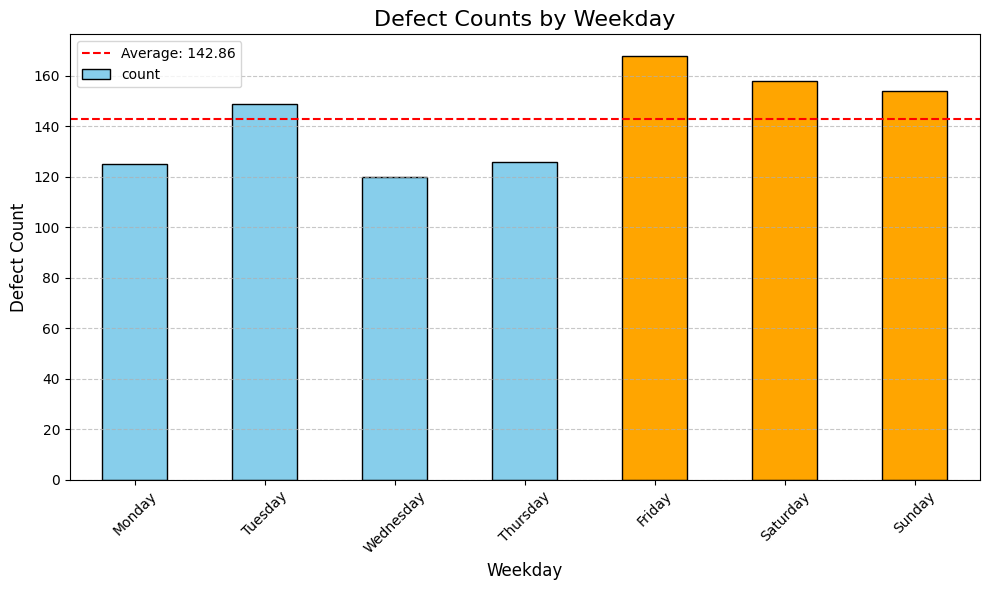

In [ ]:
# 날짜 데이터를 요일로 변환
df['defect_date'] = pd.to_datetime(df['defect_date'])  # 날짜 형식 변환
df['weekday'] = df['defect_date'].dt.day_name()  # 요일 추출

# 요일별 결함수 집계
weekday_counts = df['weekday'].value_counts()  # 요일별 집계

# 월요일부터 일요일까지의 순서대로 재정렬
weekday_order = list(calendar.day_name)  # 월요일~일요일 순서 리스트 생성
weekday_counts = weekday_counts.reindex(weekday_order, fill_value=0)  # 월요일~일요일 순서로 정렬

# 상위 3개의 요일 찾기
top_3_days = weekday_counts.nlargest(3).index  # 결함 수가 가장 많은 3개의 요일

# 막대 색상 설정 (상위 3개의 요일은 강조 색상, 나머지는 기본 색상)
colors = ['orange' if day in top_3_days else 'skyblue' for day in weekday_order]

# 평균값 계산
mean_value = weekday_counts.mean()

# 시각화
plt.figure(figsize=(10, 6))

# 막대그래프 생성 (자동 범례 제거)
weekday_counts.plot(kind='bar', color=colors, edgecolor='black', legend=False)

# 평균선 추가
plt.axhline(mean_value, color='red', linestyle='--', linewidth=1.5, label=f'Average: {mean_value:.2f}')

# 그래프 설정
plt.title('Defect Counts by Weekday', fontsize=16)  # 제목
plt.xlabel('Weekday', fontsize=12)  # x축 레이블
plt.ylabel('Defect Count', fontsize=12)  # y축 레이블
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 평균선 범례만 추가
plt.legend(fontsize=10)  # plt.axhline의 label만 범례로 표시
plt.tight_layout()

# 그래프 출력
plt.show()

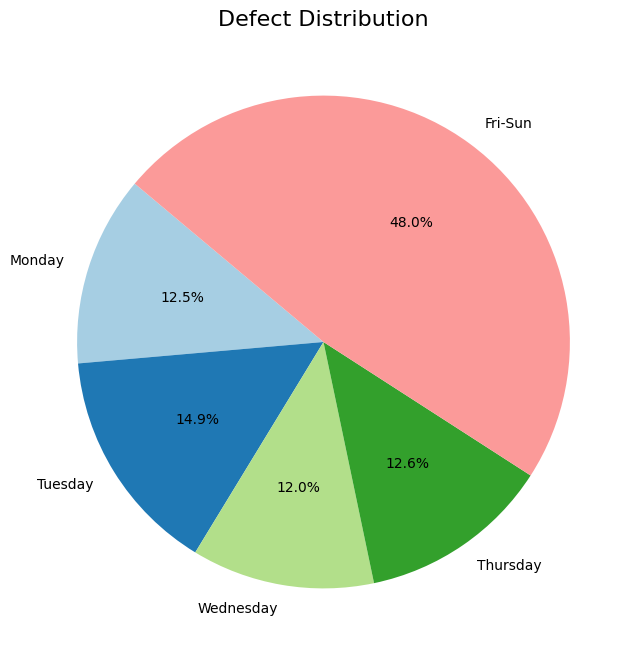

In [ ]:
# 요일 추출
df['Weekday'] = df['defect_date'].dt.day_name()

# 금, 토, 일을 Fri-Sun으로 그룹화
def group_weekday(weekday):
    if weekday in ['Friday', 'Saturday', 'Sunday']:
        return 'Fri-Sun'
    return weekday

df['Grouped_Weekday'] = df['Weekday'].apply(group_weekday)

# 그룹별 결함 수 집계
grouped_counts = df['Grouped_Weekday'].value_counts()

# 요일 순서를 정렬 (월~목, 금~일 순서)
ordered_groups = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Fri-Sun']
grouped_counts = grouped_counts.reindex(ordered_groups, fill_value=0)

# 퍼센티지 계산
total_defects = grouped_counts.sum()
percentages = (grouped_counts / total_defects) * 100

# 파이 차트 그리기
plt.figure(figsize=(8, 8))
plt.pie(
    percentages,
    labels=ordered_groups,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors[:len(ordered_groups)]
)

# 차트 제목
plt.title("Defect Distribution", fontsize=16)
plt.show()

<date 측면 분석 결과>

금요일 및 주말에 결함이 가장 많이 발생


→ 주중 작업으로 인한 피로 누적, 주말 효과로 인한 작업 동기 감소